<a href="https://colab.research.google.com/github/Glaze0/Assignment/blob/main/L3_Calculus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## Viz Helpers

In [ ]:
# === PICTURE HELPERS — run this cell, then ignore it ===============
COLORS = ["#2563eb", "#e07b39", "#3f9c7c"]
CURVE  = "#555555"

def _axes(title, xlabel, ylabel, size=(5.5, 4.4)):
    fig, ax = plt.subplots(figsize=size)
    ax.set_title(title, fontsize=11, loc="left")
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.grid(True, color="#e8e8e8"); ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    return ax

def draw_curve(f, lo, hi, title, tangents=None, paths=None,
               xlabel="w  (the knob)", ylabel="loss"):
    "Plot a curve, optionally with tangent lines and/or descent paths on it."
    ax = _axes(title, xlabel, ylabel)
    xs = np.linspace(lo, hi, 300)
    ys = np.array([f(x) for x in xs])
    ax.plot(xs, ys, color=CURVE, lw=2)
    span = (hi - lo) * 0.13
    for i, t in enumerate(tangents or []):
        s = (f(t + 1e-5) - f(t - 1e-5)) / 2e-5
        seg = np.array([t - span, t + span])
        ax.plot(seg, f(t) + s * (seg - t), color=COLORS[i % 3], lw=2)
        ax.scatter([t], [f(t)], color=COLORS[i % 3], s=70, zorder=3)
        right = t > lo + 0.66 * (hi - lo)          # keep the label inside the picture
        ax.annotate(f"slope = {s:.1f}", (t, f(t)),
                    xytext=(-8 if right else 8, 12), textcoords="offset points",
                    ha="right" if right else "left",
                    color=COLORS[i % 3], fontsize=9)
    for i, (name, path) in enumerate((paths or {}).items()):
        px = np.array(path, dtype=float)
        ax.plot(px, [f(v) for v in px], "o-", color=COLORS[i % 3],
                ms=5, lw=1.3, label=name, zorder=3)
    if paths:
        ax.legend(frameon=False, fontsize=9)
    # keep the window on the curve; a runaway path simply walks off the picture
    pad = (ys.max() - ys.min()) * 0.12
    ax.set_xlim(lo, hi); ax.set_ylim(ys.min() - pad, ys.max() + pad)
    plt.show()

def draw_contour(f, path, title, xlabel="w1", ylabel="w2"):
    "Contour map of a 2-input function, with the path taken across it."
    p = np.array(path, dtype=float)
    padx = max(1.5, 0.6 * (p[:, 0].max() - p[:, 0].min()))
    pady = max(1.5, 0.6 * (p[:, 1].max() - p[:, 1].min()))
    a = np.linspace(p[:, 0].min() - padx, p[:, 0].max() + padx, 150)
    b = np.linspace(p[:, 1].min() - pady, p[:, 1].max() + pady, 150)
    A, B = np.meshgrid(a, b)
    ax = _axes(title, xlabel, ylabel, (5.4, 4.8))
    ax.contour(A, B, f(A, B), levels=14, colors="#cfcfcf", linewidths=1)
    ax.plot(p[:, 0], p[:, 1], "o-", color=COLORS[0], ms=5, lw=1.3, label="the path taken")
    ax.scatter([p[-1, 0]], [p[-1, 1]], color=COLORS[1], s=130, zorder=4, label="where it stopped")
    ax.legend(frameon=False, fontsize=9)
    plt.show()

def draw_losses(losses, title="Loss after each step"):
    ax = _axes(title, "step", "loss")
    ax.plot(range(1, len(losses) + 1), losses, "o-", color=COLORS[0], ms=4, lw=1.3)
    plt.show()

def draw_fit(x, y, predict, xlabel, ylabel, title="The model we trained"):
    ax = _axes(title, xlabel, ylabel)
    ax.scatter(x, y, s=80, color=COLORS[0], zorder=3, label="actual data")
    xs = np.linspace(min(x), max(x), 50)
    ax.plot(xs, [predict(v) for v in xs], color=COLORS[1], lw=2, label="model prediction")
    ax.legend(frameon=False, fontsize=9)
    plt.show()

print("Picture helpers ready.")

Picture helpers ready.


## Loss Function.

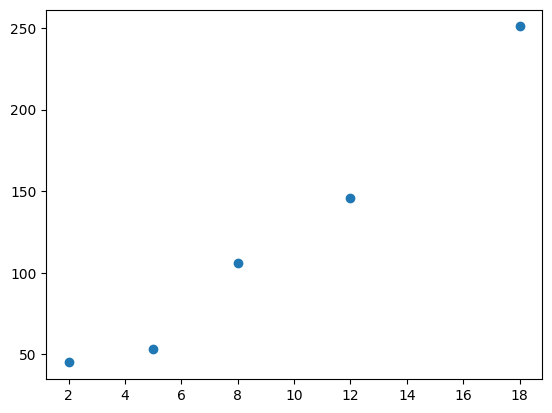

In [ ]:
distance = np.array([ 2,  5,   8,  12,  18])
fare     = np.array([ 45,  53, 106, 146, 251])
# fare     = np.array([28, 78, 121, 179, 268])

plt.scatter(distance, fare);

In [ ]:
def loss(w):
    predicted = w * distance
    err = np.mean((predicted - fare)**2)
    return err

In [ ]:
print("loss at w = 5 :", loss(5).round(1))
print("loss at w = 15:", loss(15).round(1))
print("loss at w = 16:", loss(16).round(1))
print("loss at w = 25:", loss(25).round(1))

loss at w = 5 : 7936.4
loss at w = 15: 484.4
loss at w = 16: 973.4
loss at w = 25: 15472.4


In [ ]:
def predict(x, w):
    return np.dot(x, w)

predict(15, 9)

np.int64(135)

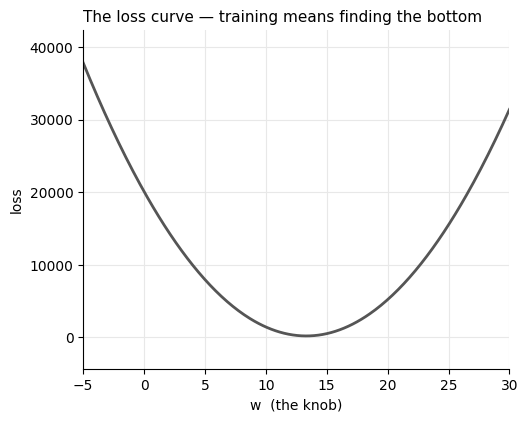

In [ ]:
draw_curve(loss, -5, 30, "The loss curve — training means finding the bottom")

In [ ]:
# w = -3, -2, -1, 0, 1, 2, 3, 4, 5, 6
# linear search.
# weights = [w1, w2]
# weights = [w1, w2, w3]
100**10

100000000000000000000

## Derivatives

In [ ]:
def fare_rule(kms):
    return 40 + 12*kms

print("from  5 km to  6 km, fare changes by:", fare_rule(6) - fare_rule(5))
print("from 20 km to 21 km, fare changes by:", fare_rule(21) - fare_rule(20))

from  5 km to  6 km, fare changes by: 12
from 20 km to 21 km, fare changes by: 12


In [ ]:
def curve(x):
    return (x-3)**2

print("from x=0 to x=1, changes by:", curve(1) - curve(0))
print("from x=2 to x=3, changes by:", curve(3) - curve(2))
print("from x=4 to x=5, changes by:", curve(5) - curve(4))

from x=0 to x=1, changes by: -5
from x=2 to x=3, changes by: -1
from x=4 to x=5, changes by: 3


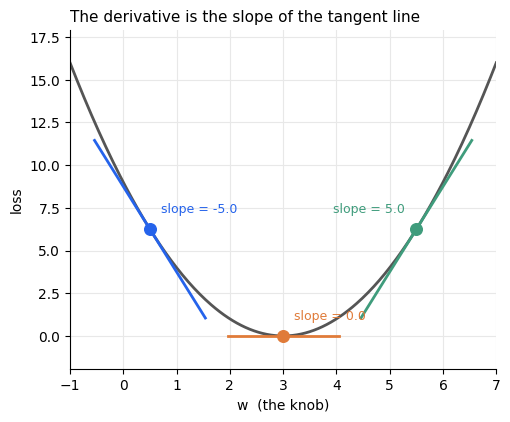

In [ ]:
draw_curve(curve, -1, 7, "The derivative is the slope of the tangent line",
           tangents=[0.5, 3, 5.5])

##slope function used for 1-D array

In [ ]:
def slope(f, x, h= 0.00001):
    return (f(x+h) - f(x)) / h

def derivate(f, x, h= 0.00001):
    return (f(x+h) - f(x)) / h

for x in [0, 1, 2, 3, 4, 5, 6]:
    print(f"x = {x},  slope = {slope(curve, x):6.2f}")

x = 0,  slope =  -6.00
x = 1,  slope =  -4.00
x = 2,  slope =  -2.00
x = 3,  slope =   0.00
x = 4,  slope =   2.00
x = 5,  slope =   4.00
x = 6,  slope =   6.00


In [ ]:
# f = (x-3)**2
# df/dx = 2x - 6

## Gradient Descent

In [ ]:
w = 6
learning_rate = 0.1

path = [w]
for _ in range(30):
    w = w - learning_rate*slope(curve, w)
    path.append(w)

print("final w:", round(w, 3), "  (the true bottom is at 3)")
print("final loss:", round(curve(w), 5))

final w: 3.004   (the true bottom is at 3)
final loss: 1e-05


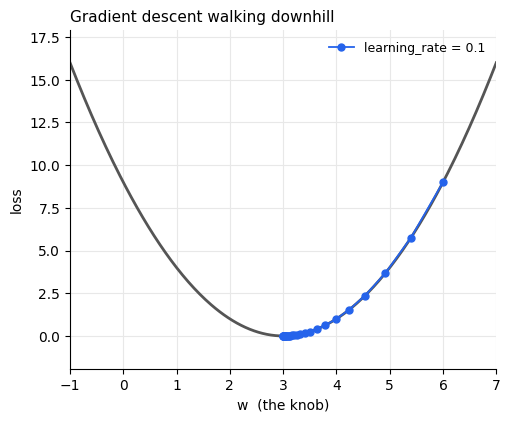

In [ ]:
draw_curve(curve, -1, 7, "Gradient descent walking downhill",
           paths={"learning_rate = 0.1": path})

In [ ]:
def bumpy(w):
    return w ** 4 - 8 * w ** 3 + 18 * w ** 2 - 11 * w

In [ ]:
w = 6
learning_rate = 0.01

path = [w]
for _ in range(30):
    w = w - learning_rate*slope(bumpy, w)
    path.append(w)

print("final w:", round(w, 3), "  (the true bottom is at 3)")
print("final loss:", round(curve(w), 5))

final w: 3.846   (the true bottom is at 3)
final loss: 0.7151


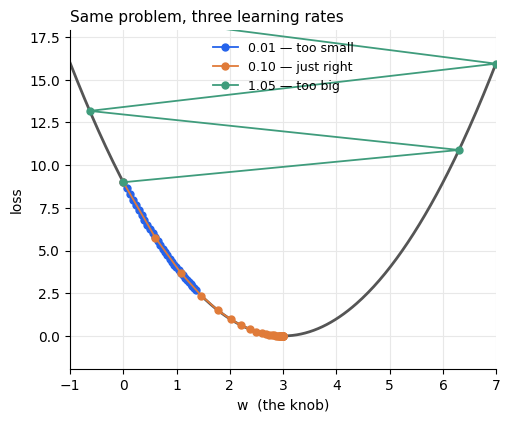

In [ ]:
def descend(start, learning_rate, steps=30):
    w = start # 2, 0, 1, 6
    path = [w]
    for _ in range(steps):
        w = w - learning_rate * slope(curve, w)
        path.append(w)
    return path

draw_curve(curve, -1, 7, "Same problem, three learning rates",
           paths={"0.01 — too small": descend(0, 0.01),
                  "0.10 — just right": descend(0, 0.1),
                  "1.05 — too big": descend(0, 1.05)})

## Partial Derivates

In [ ]:
def loss2(w1, w2):
    return (w1 - 3)**2 + (w2 - 5)**2

In [ ]:
h = 0.0001
w1 = 0
w2 = 0


slope_w1 = ( loss2(w1+h, w2) - loss2(w1, w2) )/ h   # increased w1 -> w1+h
slope_w2 = ( loss2(w1, w2+h) - loss2(w1, w2) )/ h   # increased w2 -> w2+h

print("slope along w1:", round(slope_w1, 2))
print("slope along w2:", round(slope_w2, 2))

slope along w1: -6.0
slope along w2: -10.0


## Gradient Function used for two variable `similar to slope fuction of 1-D`

In [ ]:
def gradient(f, w1, w2, h = 0.00001):
    slope_w1 = ( f(w1+h, w2) - f(w1, w2) )/ h   # increased w1 -> w1+h
    slope_w2 = ( f(w1, w2+h) - f(w1, w2) )/ h   # increased w2 -> w2+h

    return np.array([slope_w1, slope_w2])

In [ ]:
gradient(loss2, 0, 0 )

[-5.9999900003049325, -9.99998999944296]

In [ ]:
gradient(loss2, 3, 5 ).round(2)

array([0., 0.])

## ML Algo - Linear Regression

In [ ]:
print(distance)
print(fare)

[ 2  5  8 12 18]
[ 45  53 106 146 251]


In [ ]:
x = distance
y = fare
print("input x:", x)
print("output y:", y)

input x: [ 2  5  8 12 18]
output y: [ 45  53 106 146 251]


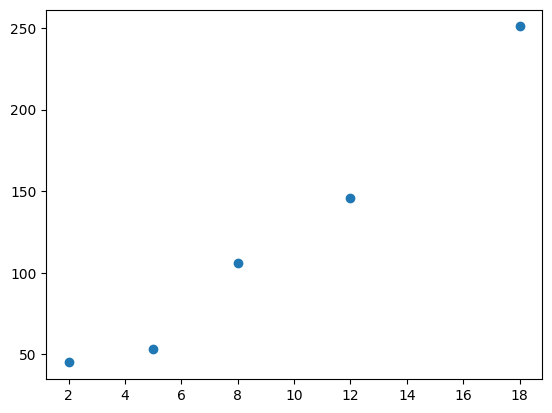

In [ ]:
plt.scatter(distance, fare);

In [ ]:
def model_loss(w1, w0):
    predicted = w1*x + w0
    return np.mean((predicted - y)**2)

In [ ]:
print(model_loss(1, 20))
print(model_loss(2, 5))
print(model_loss(20, 40))


13152.4
13550.8
11557.4


In [ ]:
weights = np.array([0,0])
learning_rate = 0.0001

history = []

for _ in range(200):
    grad = gradient(model_loss, weights[0], weights[1])
    weights = weights - learning_rate * grad
    history.append(model_loss(weights[0], weights[1]))

print("trained weights:", weights)

trained weights: [13.09817324  1.05390113]


In [ ]:
model_loss(13.23, 1.06).round()

np.float64(168.0)

In [ ]:
history[:10]

[np.float64(19188.24479982018),
 np.float64(18338.798741043265),
 np.float64(17527.288436844865),
 np.float64(16752.01969870466),
 np.float64(16011.374000101907),
 np.float64(15303.805096334274),
 np.float64(14627.835797405573),
 np.float64(13982.05488367238),
 np.float64(13365.11415967874),
 np.float64(12775.725639795146)]

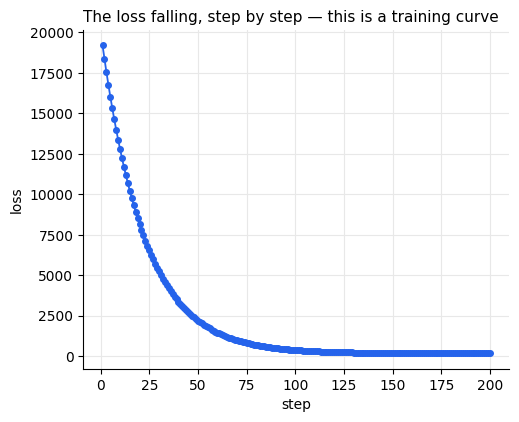

In [ ]:
draw_losses(history, "The loss falling, step by step — this is a training curve")

In [ ]:
# 13kms

In [ ]:
def predict(km):
    return weights[0]*km + weights[1]

In [ ]:
predict(13)

np.float64(171.33015330208423)

In [ ]:
distance

array([ 2,  5,  8, 12, 18])

In [ ]:
predict(distance)

array([ 27.25024762,  66.54476735, 105.83928708, 158.23198006,
       236.82101952])

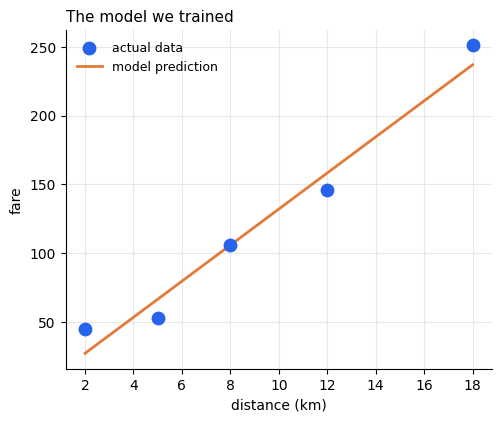

In [ ]:
draw_fit(distance, fare, predict, "distance (km)", "fare")

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(distance.reshape(5, 1), fare) # learns allll the weightssssss. w1, w0

LinearRegression()

In [ ]:
model.coef_, model.intercept_

(array([13.23076923]), np.float64(1.1230769230769369))

In [ ]:
model.predict([[13]])

array([173.12307692])